# Brazilian E-Commerce EDA — Olist Dataset

In [1]:
import sys
import warnings
sys.path.insert(0, "..")   # makes src/ importable from notebooks/
warnings.filterwarnings("ignore")
import logging
logging.basicConfig(level=logging.WARNING)  # suppress INFO in notebook

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Import your own modules
from src.eda_pipeline import run_full_pipeline
from src.data_analyzer import (
    delivery_time_by_seller,   
    late_delivery_by_month,
    worst_sellers_by_on_time_rate,
    monthly_order_trends,
    weekly_volume_with_rolling_avg,
    detect_growth_periods,
    peak_hour_analysis,
)

# Seaborn style — your consistent professional style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

## 1. Business Context & Dataset Overview

**Business question:** What operational and logistical patterns in the 
Olist e-commerce platform explain customer satisfaction and delivery 
performance from 2016–2018?

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
- Source: Kaggle (olistbr/brazilian-ecommerce)  
- 8 relational tables, ~100K orders, Sep 2016 – Oct 2018  
- Key tables used: orders, order_items, customers, products, sellers

**Analysis goals:**
1. Identify product categories and sellers with worst delivery performance
2. Measure monthly trend of late deliveries over time
3. Detect revenue growth patterns and seasonal spikes
4. Surface peak order hours for operational planning

In [2]:
df = run_full_pipeline("../data/raw/olist/")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nDate range: {df['order_purchase_timestamp'].min()} → {df['order_purchase_timestamp'].max()}")
df.head(3)

Shape: (110123, 18)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'late_delivery', 'purchase_month', 'purchase_hour', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Date range: 2016-09-15 12:16:38 → 2018-08-29 15:00:37


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,late_delivery,purchase_month,purchase_hour,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,2017-10,10,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,2018-07,20,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False,2018-08,8,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22


## 2. Data Loading & Quality Report

In [3]:
from src.data_loader import load_csv_safe
from src.data_cleaner import audit_nulls, optimize_memory

# Load raw orders for quality audit (before pipeline processing)
orders_raw = load_csv_safe("../data/raw/olist/olist_orders_dataset.csv")

# Null report
null_report = audit_nulls(orders_raw)
print("=== NULL AUDIT ===")
print(null_report.to_string(index=False))

# Memory profile
orders_opt, mem_log = optimize_memory(orders_raw)
before = orders_raw.memory_usage(deep=True).sum() / 1e6
after = orders_opt.memory_usage(deep=True).sum() / 1e6
print(f"\n=== MEMORY OPTIMISATION ===")
print(f"Before: {before:.2f} MB  →  After: {after:.2f} MB  ({(1-after/before)*100:.1f}% reduction)")
print(f"\nConversions: {mem_log}")

=== NULL AUDIT ===
                       column  null_count  null_pct suggested_strategy
            order_approved_at         160      0.16          drop rows
 order_delivered_carrier_date        1783      1.79          drop rows
order_delivered_customer_date        2965      2.98          drop rows



=== MEMORY OPTIMISATION ===
Before: 55.51 MB  →  After: 49.84 MB  (10.2% reduction)

Conversions: {'order_status': 'object → category'}


**Null Audit Findings:**
The null values found represent orders that are currently in-transit or were canceled. We do not drop these rows here; they are safely handled downstream when we filter for "delivered" orders.

## 3. Feature Engineering


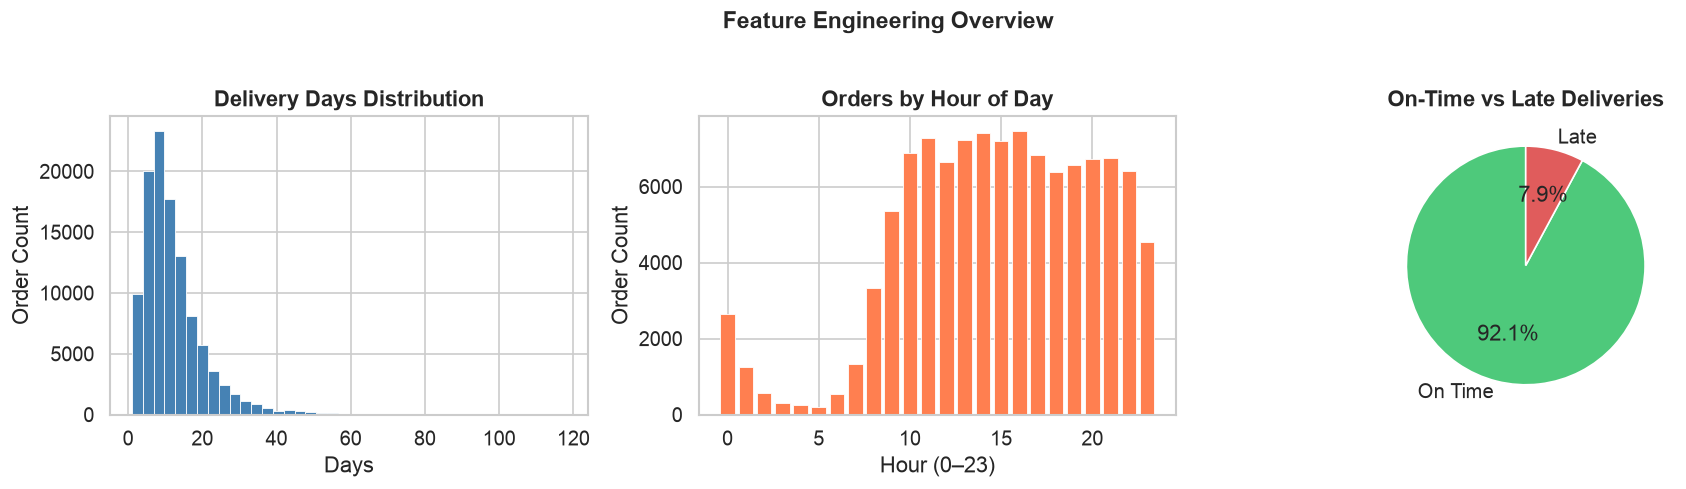


Engineered features: delivery_days, late_delivery, purchase_month, purchase_hour
Late delivery rate: 7.9%
Median delivery time: 10 days


In [4]:
# Feature distribution overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Delivery days distribution
axes[0].hist(df['delivery_days'].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Delivery Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Order Count')

# Purchase hour distribution  
hour_data = df['purchase_hour'].value_counts().sort_index()
axes[1].bar(hour_data.index, hour_data.values, color='coral', edgecolor='white', linewidth=0.5)
axes[1].set_title('Orders by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Order Count')

# Late delivery pie
late_counts = df['late_delivery'].value_counts()
axes[2].pie(late_counts, labels=['On Time', 'Late'], autopct='%1.1f%%', 
            colors=['#4ec97b', '#e05c5c'], startangle=90)
axes[2].set_title('On-Time vs Late Deliveries', fontweight='bold')

plt.suptitle('Feature Engineering Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nEngineered features: delivery_days, late_delivery, purchase_month, purchase_hour")
print(f"Late delivery rate: {df['late_delivery'].mean()*100:.1f}%")
print(f"Median delivery time: {df['delivery_days'].median():.0f} days")

## 4. Business Question Analysis

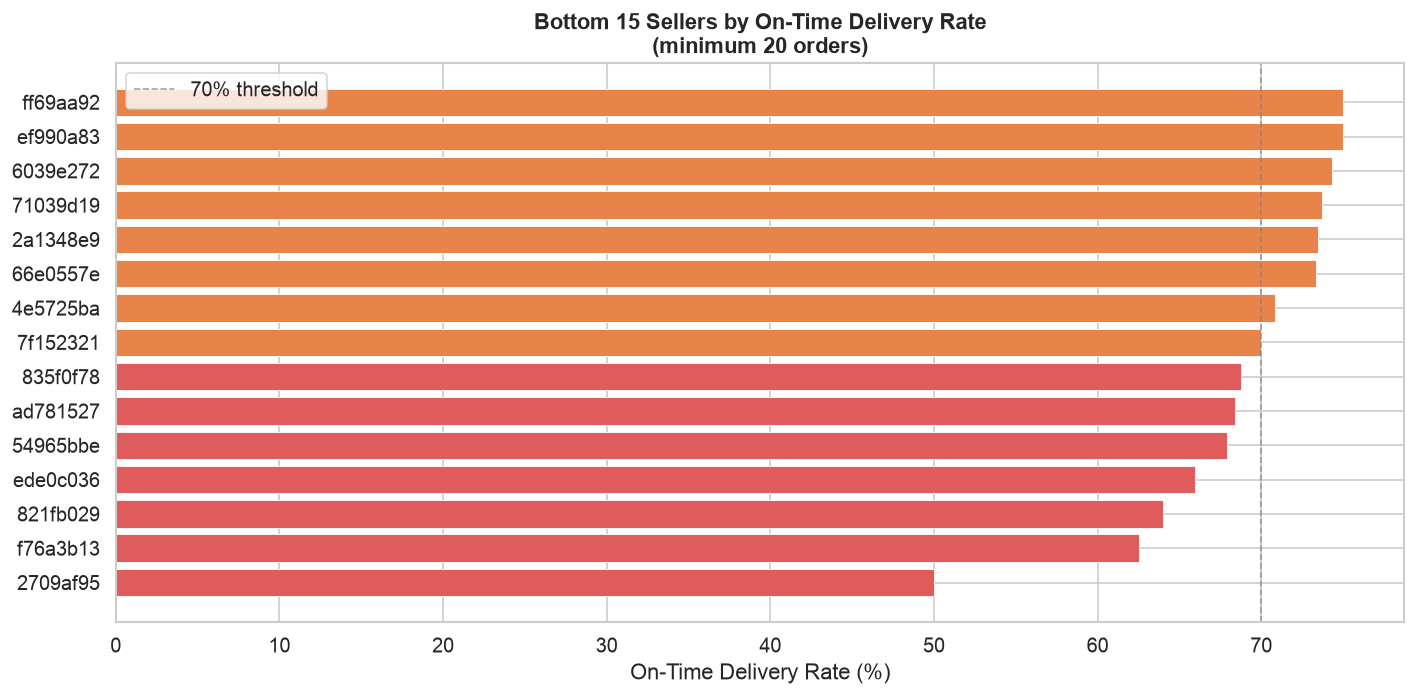

In [5]:
worst_sellers = worst_sellers_by_on_time_rate(df, min_orders=20, top_n=15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    worst_sellers['seller_id'].str[:8],  # truncate long IDs
    worst_sellers['on_time_rate'] * 100,
    color=['#e05c5c' if r < 0.7 else '#e8834a' for r in worst_sellers['on_time_rate']],
    edgecolor='white', linewidth=0.5
)
ax.axvline(x=70, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='70% threshold')
ax.set_xlabel('On-Time Delivery Rate (%)')
ax.set_title('Bottom 15 Sellers by On-Time Delivery Rate\n(minimum 20 orders)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

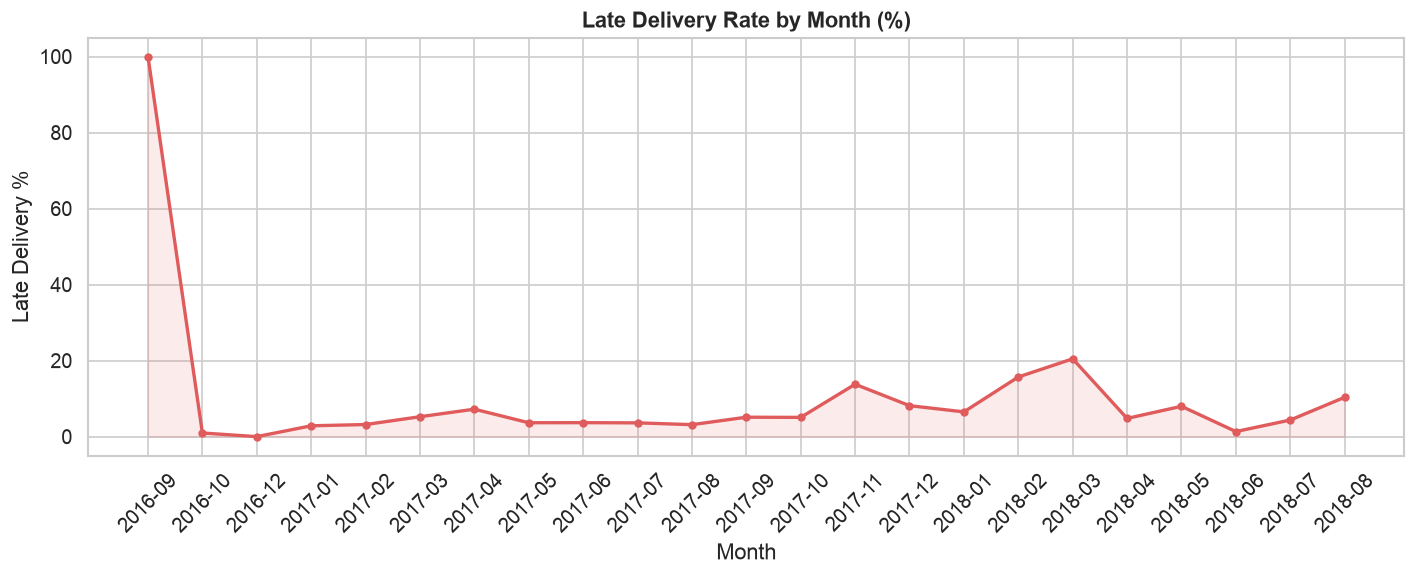


Worst month: 2016-09 — 100.0% late


In [6]:
monthly_late = late_delivery_by_month(df).set_index("purchase_month")
# .set_index() here is for plotting convenience only — the function itself
# returns purchase_month as a column (tidy data, per Day 4's design). We
# index it here so the x-axis ticks show actual months instead of 0..n.

fig, ax = plt.subplots(figsize=(12, 5))
x_values = monthly_late.index.astype(str)
ax.plot(x_values, monthly_late['pct_late'], 
        color='#e05c5c', linewidth=2, marker='o', markersize=4)
ax.fill_between(x_values, monthly_late['pct_late'], alpha=0.12, color='#e05c5c')
ax.set_title('Late Delivery Rate by Month (%)', fontweight='bold')
ax.set_ylabel('Late Delivery %')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nWorst month: {monthly_late['pct_late'].idxmax()} — {monthly_late['pct_late'].max():.1f}% late")

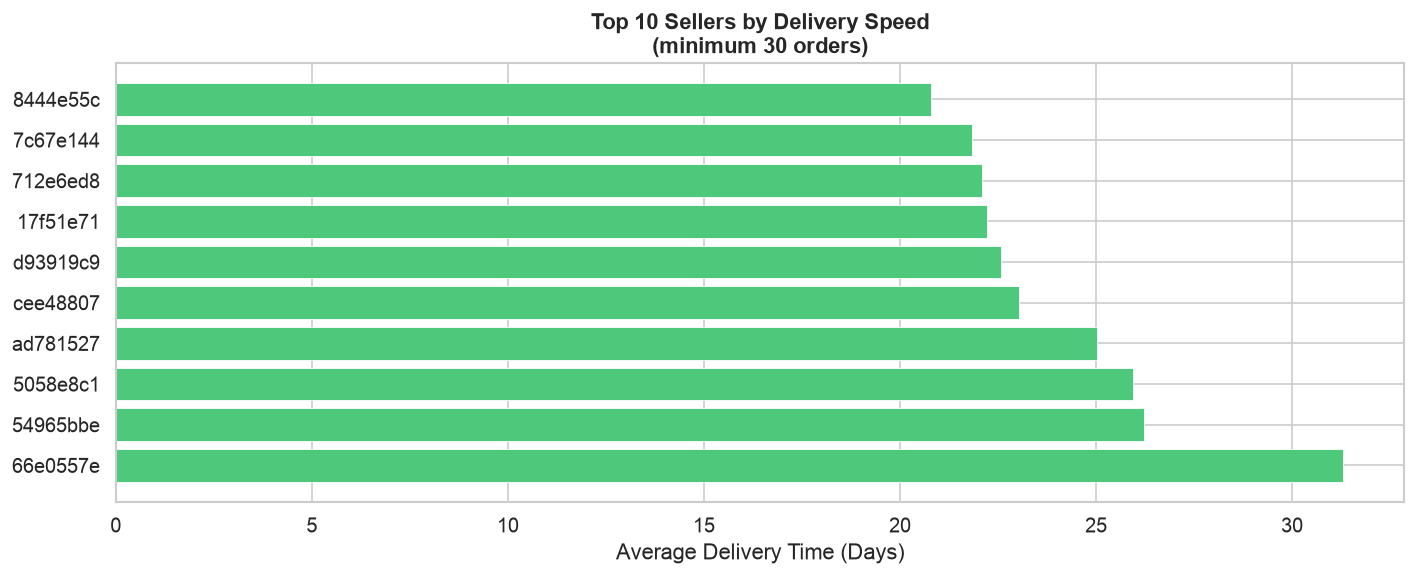

In [7]:
# 1. Get data: top 10 fastest sellers with minimum 30 orders
top_sellers = delivery_time_by_seller(df, min_orders=30).head(10)

# 2. Sort values so the lowest delivery time is at the top of the chart
top_sellers = top_sellers.sort_values('avg_delivery_days', ascending=False)

# 3. Build the chart
fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(
    top_sellers['seller_id'].str[:8],  # Truncate IDs to 8 characters like Chart 1
    top_sellers['avg_delivery_days'],
    color='#4ec97b',                   # Green to signify "good" performance
    edgecolor='white', 
    linewidth=0.5
)

ax.set_xlabel('Average Delivery Time (Days)')
ax.set_title('Top 10 Sellers by Delivery Speed\n(minimum 30 orders)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Time-Series Trends


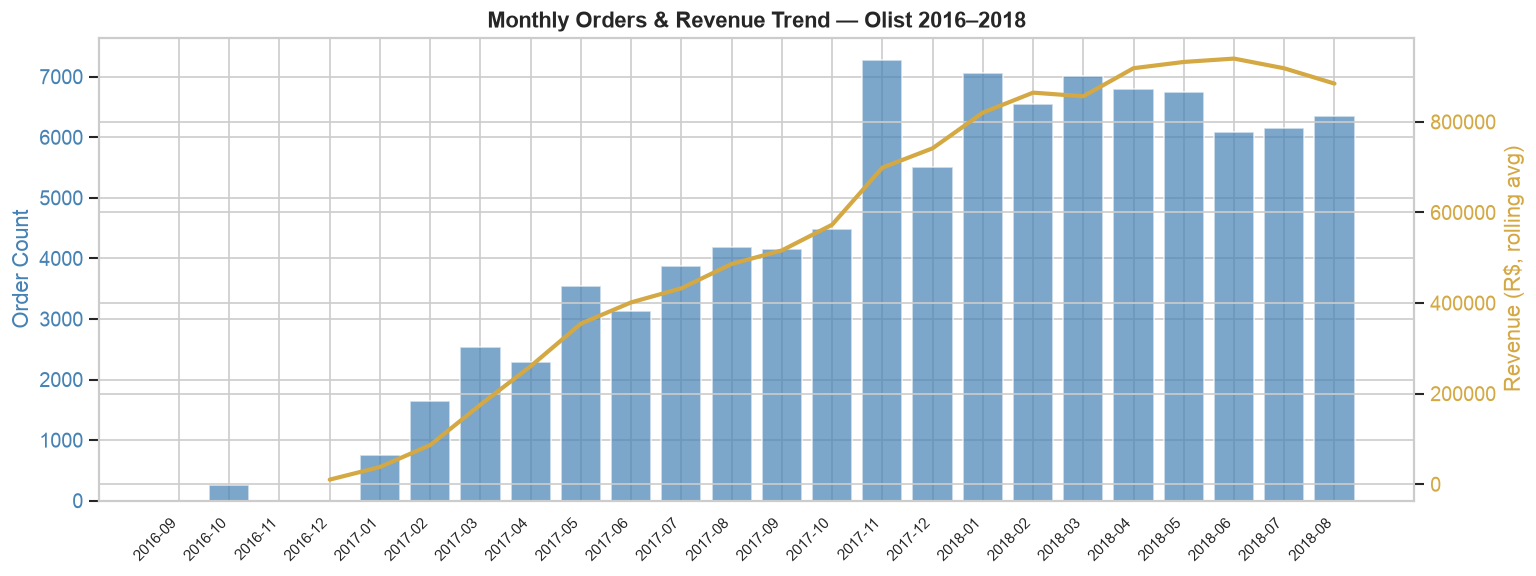

In [8]:
monthly = monthly_order_trends(df)

fig, ax1 = plt.subplots(figsize=(13, 5))

# Bar chart for order count
ax1.bar(range(len(monthly)), monthly['order_count'], 
        color='steelblue', alpha=0.7, label='Order Count')
ax1.set_ylabel('Order Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line for rolling revenue
ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['revenue_4wk_rolling'], 
         color='#d4a843', linewidth=2.5, label='4-Month Rolling Revenue')
ax2.set_ylabel('Revenue (R$, rolling avg)', color='#d4a843')
ax2.tick_params(axis='y', labelcolor='#d4a843')

# X-axis labels
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(
    [str(m)[:7] for m in monthly['month']], 
    rotation=45, ha='right', fontsize=9
)

ax1.set_title('Monthly Orders & Revenue Trend — Olist 2016–2018', fontweight='bold')
plt.tight_layout()
plt.show()

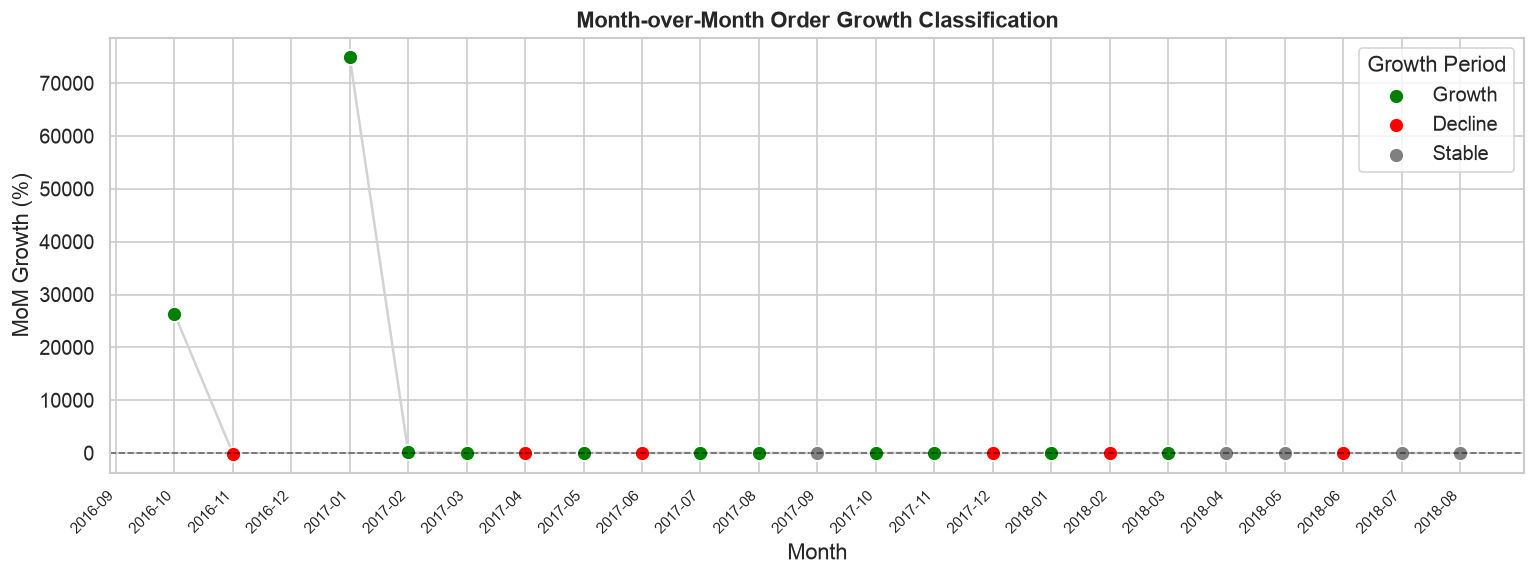

In [9]:
# 1. Call the function to get the data
growth_df = detect_growth_periods(df)

# 2. Set up the figure
fig, ax = plt.subplots(figsize=(13, 5))

# 3. Create string versions of the dates for the X-axis so Matplotlib doesn't crash
x_values = growth_df['month'].astype(str).str[:7]

# 4. Plot the plain background line connecting the dots
ax.plot(x_values, growth_df['mom_order_growth'], color='lightgray', zorder=1)

# 5. Define the exact colors requested by the client prompt
colors = {
    'growth': 'green', 
    'decline': 'red', 
    'stable': 'grey', 
    'unknown': 'black' # Fallback for the first month which has no MoM data
}

# 6. Plot the colored dots on top of the line
for label in ['growth', 'decline', 'stable', 'unknown']:
    # Filter the dataframe for each specific status
    subset = growth_df[growth_df['period_label'] == label]
    
    # FIX: Drop the NaN values so Matplotlib doesn't crash on the 'unknown' month
    valid_subset = subset.dropna(subset=['mom_order_growth'])
    
    # Only draw if there is valid data for this category
    if not valid_subset.empty:
        subset_x = valid_subset['month'].astype(str).str[:7]
        
        ax.scatter(
            subset_x, 
            valid_subset['mom_order_growth'], 
            color=colors[label], 
            label=label.capitalize(), 
            s=80, 
            zorder=2, 
            edgecolor='white'
        )

# 7. Add a zero-line so it is easy to see exactly where growth turns negative
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# 8. Formatting the chart
ax.set_title('Month-over-Month Order Growth Classification', fontweight='bold')
ax.set_ylabel('MoM Growth (%)')
ax.set_xlabel('Month')

# 9. Clean up labels and add legend
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.legend(title='Growth Period')

plt.tight_layout()
plt.show()